In [ ]:
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
color= sns.color_palette("pastel")
sns.set(style="whitegrid", context="talk", font_scale=0.8, palette=color,rc={'figure.figsize':(8,4)})

Note: you may need to restart the kernel to use updated packages.


In [1]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f" Ther are {len(df.index.unique())} unique customer in {df.shape[0]}")

 Ther are 7043 unique customer in 7043


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Totalcharges  is object . change it to numeric.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
# All Nans of TotalCharges has zero tenure. That's why we can assume TotalCharges = MonthlyCharges. They're fresh customers.
df [df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
# Change Total Charges values with Monthly Charges where is nan.
df.loc[df['TotalCharges'].isnull() ,'TotalCharges'] = df.loc[df['TotalCharges'].isnull() , 'MonthlyCharges']

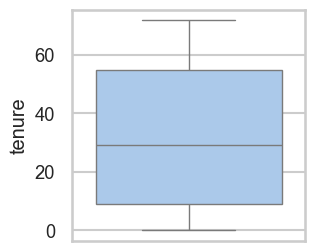

In [8]:
#check outlier 
plt.figure(figsize = (3,3))
sns.boxplot(df.tenure)
plt.show()

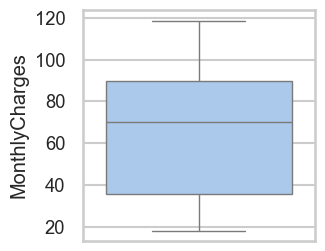

In [9]:
#check outlier 
plt.figure(figsize = (3,3))
sns.boxplot(df.MonthlyCharges)
plt.show()

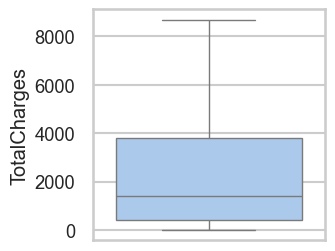

In [10]:
#check outlier 
plt.figure(figsize = (3,3))
sns.boxplot(df.TotalCharges)
plt.show()

In [11]:
#lets look all values in every columns.
for i in df.columns:
    print(f"column '{i}' has : {df [i].unique()}")

column 'customerID' has : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
column 'gender' has : ['Female' 'Male']
column 'SeniorCitizen' has : [0 1]
column 'Partner' has : ['Yes' 'No']
column 'Dependents' has : ['No' 'Yes']
column 'tenure' has : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
column 'PhoneService' has : ['No' 'Yes']
column 'MultipleLines' has : ['No phone service' 'No' 'Yes']
column 'InternetService' has : ['DSL' 'Fiber optic' 'No']
column 'OnlineSecurity' has : ['No' 'Yes' 'No internet service']
column 'OnlineBackup' has : ['Yes' 'No' 'No internet service']
column 'DeviceProtection' has : ['No' 'Yes' 'No internet service']
column 'TechSupport' has : ['No' 'Yes' 'No internet service']
column 'StreamingTV' has : ['No' 'Yes' 'No internet service']
column 'Stream

In [12]:
# Get dummies for every value in categoric features.
# Get dummies for just positive values in binary features.
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categoric_features = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]
binary_features = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
df_encoded =  pd.get_dummies(df,columns = categoric_features)
df_encoded = pd.get_dummies(df_encoded ,columns= binary_features , drop_first= True)

In [13]:
print(f"Data Columns: {len(df.columns)}\nEncoded Data Columns: {len(df_encoded.columns)}")

Data Columns: 21
Encoded Data Columns: 42


In [14]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   object 
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   MultipleLines_No                         7043 non-null   bool   
 5   MultipleLines_No phone service           7043 non-null   bool   
 6   MultipleLines_Yes                        7043 non-null   bool   
 7   InternetService_DSL                      7043 non-null   bool   
 8   InternetService_Fiber optic              7043 non-null   bool   
 9   InternetService_No                       7043 non-null   bool   
 10  OnlineSecurity_No                        7043 no

# Feature Engineering

In [15]:
# Later use to compare the benefits of feature engineering
data_test = df_encoded.copy()

In [16]:
#investigate tenur , totalcharge , monthlycharges
# Create a new feature for average charges but when tenure is 0 we need to assign TotalCharges
df_encoded["AverageCharges"] = df_encoded["TotalCharges"] / df_encoded["tenure"]
df_encoded.loc[df_encoded['tenure'] == 0 ,"AverageCharges"] = df_encoded['TotalCharges']

In [17]:
# Create a new feature when monthly charges are above average charges
df_encoded["AboveAverageCharges"] = (df_encoded["MonthlyCharges"] >df_encoded["AverageCharges"].mean()).astype(int)

In [18]:
#This information can be usefull 
df_encoded["AboveAverageCharges"].value_counts()

AboveAverageCharges
1    3923
0    3120
Name: count, dtype: int64

In [19]:
# ...No internet repeat itself for 7 times
df_encoded.mean(numeric_only=True)


tenure                                       32.371149
MonthlyCharges                               64.761692
TotalCharges                               2279.798992
MultipleLines_No                              0.481329
MultipleLines_No phone service                0.096834
MultipleLines_Yes                             0.421837
InternetService_DSL                           0.343746
InternetService_Fiber optic                   0.439585
InternetService_No                            0.216669
OnlineSecurity_No                             0.496663
OnlineSecurity_No internet service            0.216669
OnlineSecurity_Yes                            0.286668
OnlineBackup_No                               0.438450
OnlineBackup_No internet service              0.216669
OnlineBackup_Yes                              0.344881
DeviceProtection_No                           0.439443
DeviceProtection_No internet service          0.216669
DeviceProtection_Yes                          0.343888
TechSuppor

In [20]:

# Let's get rid of them and just keep InternetService_No
columns_to_delete = [
                    'OnlineSecurity_No internet service',
                    'OnlineBackup_No internet service',
                    'DeviceProtection_No internet service',
                    'TechSupport_No internet service',
                    'StreamingTV_No internet service',
                    'StreamingMovies_No internet service']
df_encoded.drop(columns=columns_to_delete, inplace=True)
print(f"Number of Columns: {len(df_encoded.columns)}")

Number of Columns: 38


In [21]:
# Add a column to identify persons who use services most
services = [
    'MultipleLines_Yes',
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'PhoneService_Yes',
    'PaperlessBilling_Yes']

# Create a new column to identify persons who use services the most
df_encoded['ServicesMost'] = df_encoded[services].mean(axis=1)

In [22]:
df_encoded.ServicesMost.value_counts(ascending=True)

ServicesMost
0.909091    130
0.818182    356
0.727273    597
0.272727    722
0.181818    787
0.636364    813
0.090909    894
0.363636    898
0.454545    900
0.545455    946
Name: count, dtype: int64

In [23]:
# There is no need for No columns anymore.
df_encoded.columns

Index(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_Yes',
       'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'PaperlessBilling_Yes', 'Churn_Yes',
       'AverageCharges', 'AboveAverageCharges', 'ServicesMost'],
      dtype='object')

In [24]:
columns_to_keep = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_Yes',
                     'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_Yes',
                     'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
                     'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
                     'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
                     'PaymentMethod_Credit card (automatic)', 'InternetService_No',
                     'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
                     'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes',
                     'PhoneService_Yes', 'PaperlessBilling_Yes', 'Churn_Yes',
                     'AverageCharges', 'AboveAverageCharges', 'ServicesMost']

df_encoded = df_encoded[columns_to_keep]

In [25]:
print(f"Total columns left : {df_encoded.shape[1]}")

Total columns left : 30


In [27]:
# We'll use Kmeans to assign clusters as new feauture
%pip install -q scikit-learn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Scale data using MinMaxScaler because it's mostly binary data
scaler = MinMaxScaler()
scaled_data = df_encoded.drop("Churn_Yes", axis=1)  
scaled_data = scaler.fit_transform(scaled_data)

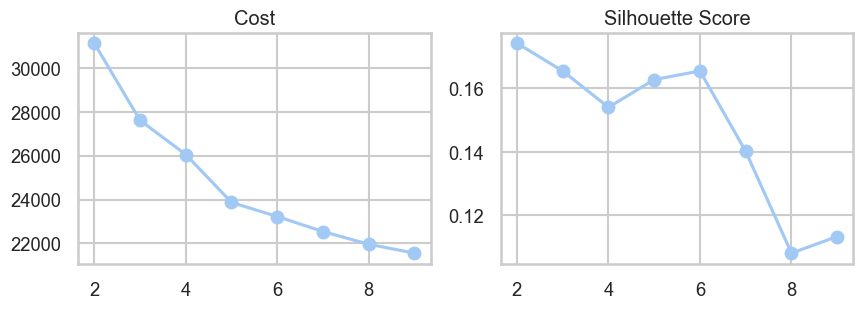

In [30]:
# Calculate and plot costs and silhouette scores for KMeans
costs = []
silhouette_scores = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(scaled_data)
    costs.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(2, 10), costs, marker='o')
plt.title('Cost')

plt.subplot(1, 2, 2)
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.show() 

In [31]:
# According to results my intuition is picking K-Means with n = 5
# It's a maximum number we can assign as cluster number for adding a new feature to improve model's performance
km = KMeans(n_clusters=5, n_init=5, verbose=0, random_state=0)
km.fit_predict(scaled_data)
df_encoded["cluster"] = km.labels_

In [34]:
df_encoded.describe()

,tenure,MonthlyCharges,TotalCharges,AverageCharges,AboveAverageCharges,ServicesMost,cluster
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,64.762906,0.557007,0.430769,1.723413
std,24.559481,30.090047,2266.730170,30.189796,0.496775,0.225187,1.419986
min,0.000000,18.250000,18.800000,13.775000,0.000000,0.090909,0.000000
25%,9.000000,35.500000,398.550000,35.935156,0.000000,0.272727,0.000000
50%,29.000000,70.350000,1394.550000,70.337500,1.000000,0.454545,2.000000
75%,55.000000,89.850000,3786.600000,90.174158,1.000000,0.636364,3.000000
max,72.000000,118.750000,8684.800000,121.400000,1.000000,0.909091,4.000000


In [35]:
# Divide data to different categories for better understanding
numerical = ['tenure', 'MonthlyCharges', 'TotalCharges',
             'AverageCharges', 'AboveAverageCharges', 'ServicesMost', 'Churn_Yes']

services = ['MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_Yes',
            'OnlineBackup_Yes', 'DeviceProtection_Yes','TechSupport_Yes', 'StreamingTV_Yes',
            'StreamingMovies_Yes', 'InternetService_No', 'PhoneService_Yes', 'PaperlessBilling_Yes', 'ServicesMost', 'Churn_Yes']

demographic = ['gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'Churn_Yes', 'cluster']

other = ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_Yes']

In [37]:
# Check average correlation for all
correlation_matrix_all = df_encoded.corr()
abs(correlation_matrix_all).mean()

tenure                                     0.294068
MonthlyCharges                             0.379600
TotalCharges                               0.378008
MultipleLines_Yes                          0.231331
InternetService_DSL                        0.178432
InternetService_Fiber optic                0.312482
OnlineSecurity_Yes                         0.223823
OnlineBackup_Yes                           0.242595
DeviceProtection_Yes                       0.263080
TechSupport_Yes                            0.243232
StreamingTV_Yes                            0.271363
StreamingMovies_Yes                        0.273904
Contract_Month-to-month                    0.260271
Contract_One year                          0.130568
Contract_Two year                          0.216384
PaymentMethod_Bank transfer (automatic)    0.132723
PaymentMethod_Credit card (automatic)      0.135820
InternetService_No                         0.315233
PaymentMethod_Electronic check             0.214860
PaymentMetho

In [38]:
# Check average correlation for numerical
correlation_matrix_num = df_encoded[numerical].corr()
abs(correlation_matrix_num).mean()

tenure                 0.469757
MonthlyCharges         0.690098
TotalCharges           0.656670
AverageCharges         0.688903
AboveAverageCharges    0.617897
ServicesMost           0.661954
Churn_Yes              0.308525
dtype: float64

In [39]:
# Check average correlation for services
correlation_matrix_serv = df_encoded[services].corr()
abs(correlation_matrix_serv).mean()

MultipleLines_Yes              0.278087
InternetService_DSL            0.284384
InternetService_Fiber optic    0.348374
OnlineSecurity_Yes             0.272758
OnlineBackup_Yes               0.299631
DeviceProtection_Yes           0.320249
TechSupport_Yes                0.297091
StreamingTV_Yes                0.333137
StreamingMovies_Yes            0.334606
InternetService_No             0.409181
PhoneService_Yes               0.190831
PaperlessBilling_Yes           0.229496
ServicesMost                   0.493448
Churn_Yes                      0.180920
dtype: float64

In [40]:
# Check average correlation for demographic
correlation_matrix_serv = df_encoded[demographic].corr()
abs(correlation_matrix_serv).mean()

gender_Male        0.172026
SeniorCitizen_1    0.255896
Partner_Yes        0.320428
Dependents_Yes     0.346476
Churn_Yes          0.311943
cluster            0.350533
dtype: float64

In [42]:
# Check average correlation for other
correlation_matrix_other = df_encoded[other].corr()
abs(correlation_matrix_other).mean()

Contract_Month-to-month                    0.414516
Contract_One year                          0.283795
Contract_Two year                          0.353622
PaymentMethod_Bank transfer (automatic)    0.306653
PaymentMethod_Credit card (automatic)      0.314611
PaymentMethod_Electronic check             0.395288
PaymentMethod_Mailed check                 0.257844
Churn_Yes                                  0.316377
dtype: float64

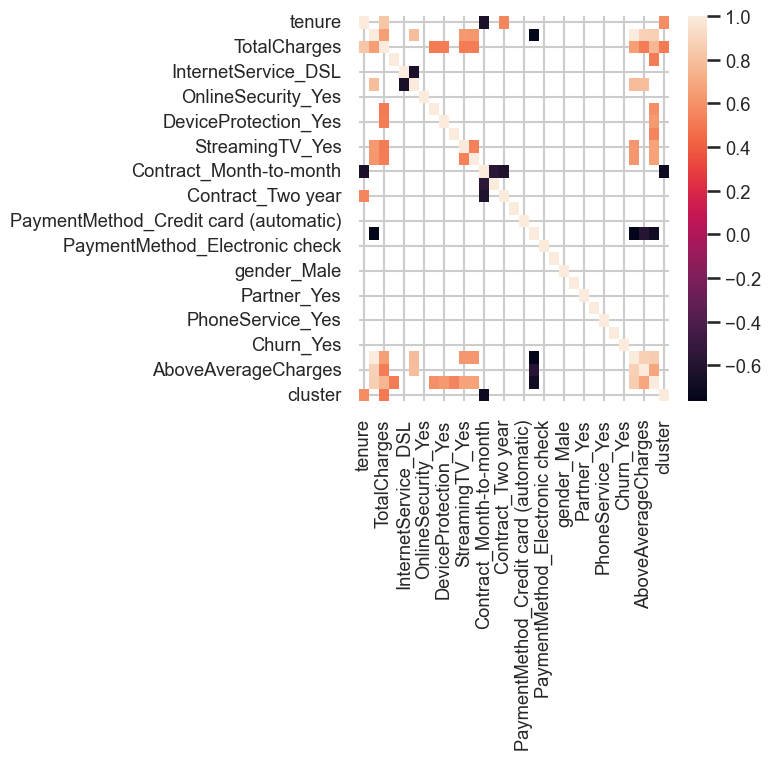

In [47]:
mask = (np.abs(correlation_matrix_all)<0.5)
plt.figure(figsize=(5,5))
sns.heatmap(correlation_matrix_all,mask=mask)
plt.show()

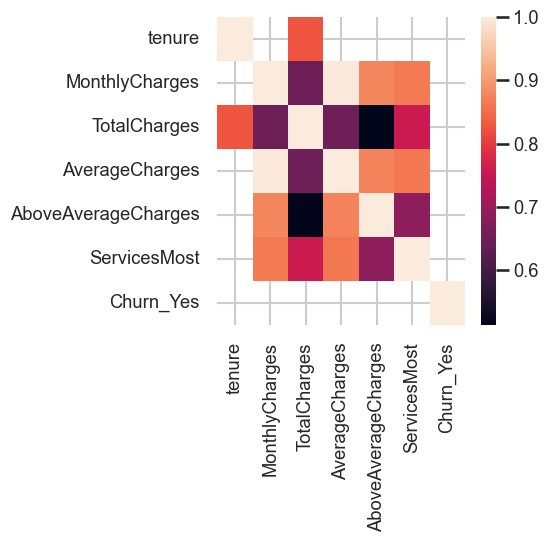

In [53]:
mask = (np.abs(correlation_matrix_num)<0.5)
plt.figure(figsize=(4,4))
sns.heatmap(correlation_matrix_num,mask=mask)
plt.show()

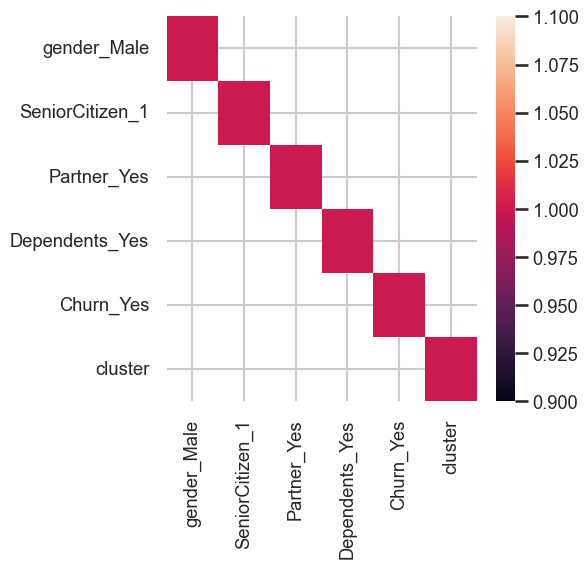

In [52]:
mask = (np.abs(correlation_matrix_serv)<0.5)
plt.figure(figsize=(5,5))
sns.heatmap(correlation_matrix_serv,mask=mask)
plt.show()

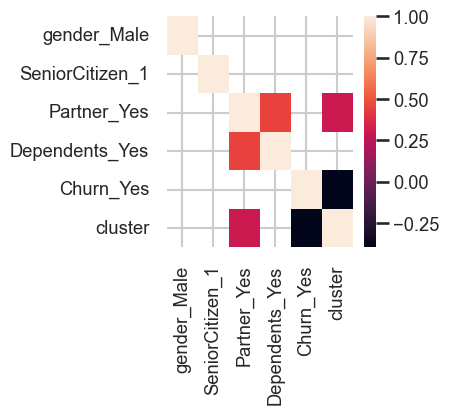

In [55]:
# Create a correlation matrix heatmap for demographic
correlation_matrix_demo = df_encoded[demographic].corr()
mask = (np.abs(correlation_matrix_demo) < 0.3)
plt.figure(figsize=(3, 3))
sns.heatmap(correlation_matrix_demo, mask=mask)
plt.show()

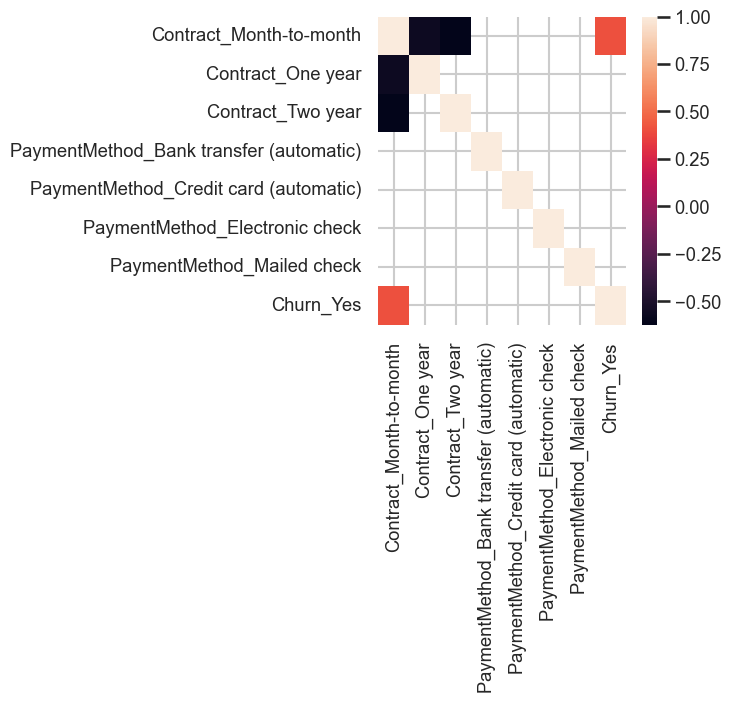

In [58]:
# Create a correlation matrix heatmap for other
mask = (np.abs(correlation_matrix_other) < 0.4)
plt.figure(figsize=(4,4))
sns.heatmap(correlation_matrix_other, mask=mask)
plt.show()

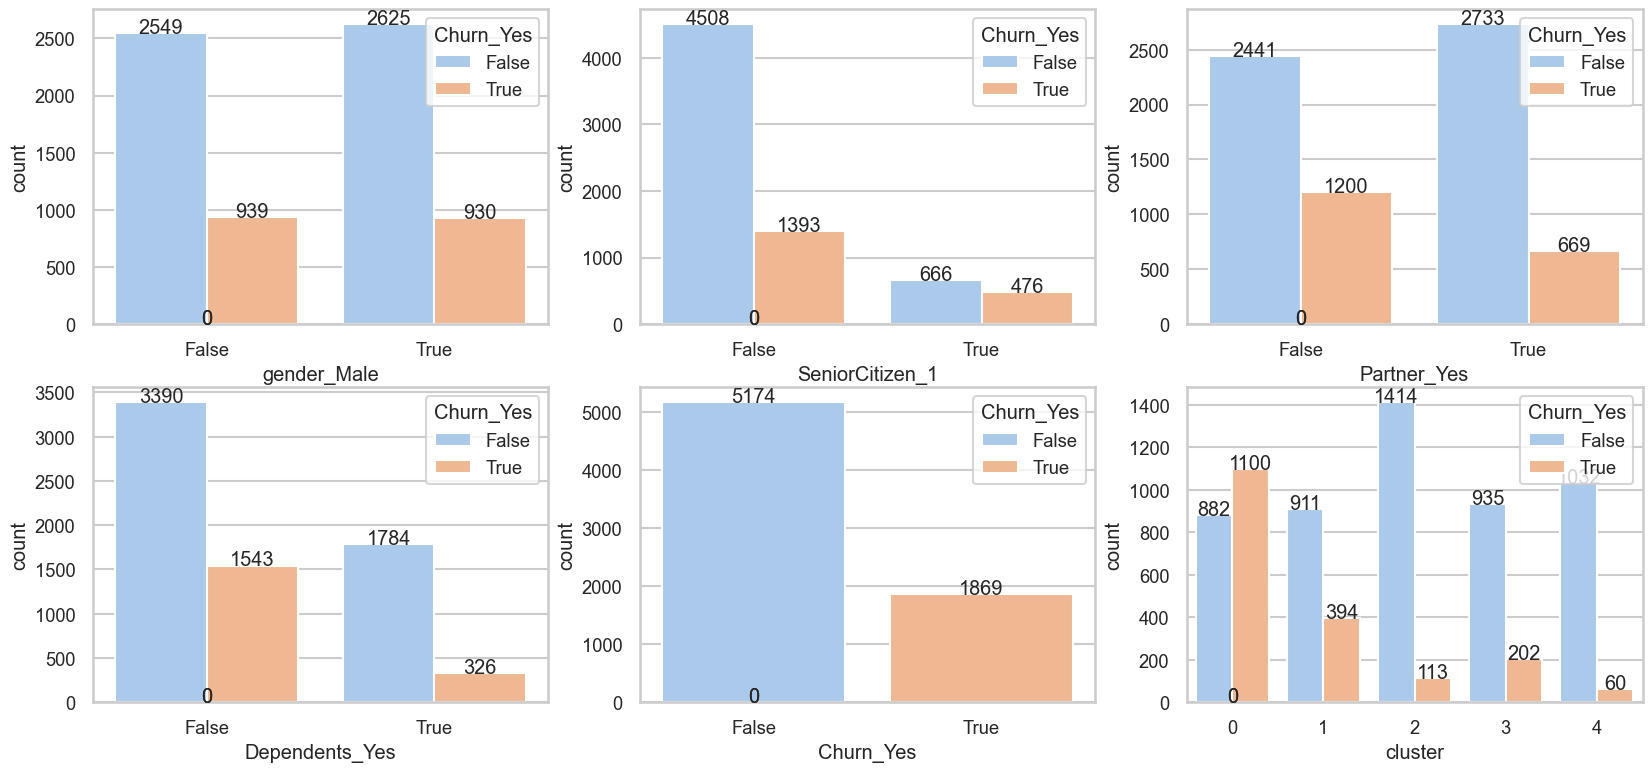

In [60]:
# Create countplot for every demographic features
plt.figure(figsize=(20,9))
for i, column in enumerate(df_encoded[demographic]):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df_encoded[demographic], x=column, hue="Churn_Yes")
    for p in plt.gca().patches:
        plt.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), ha='center')
plt.show()

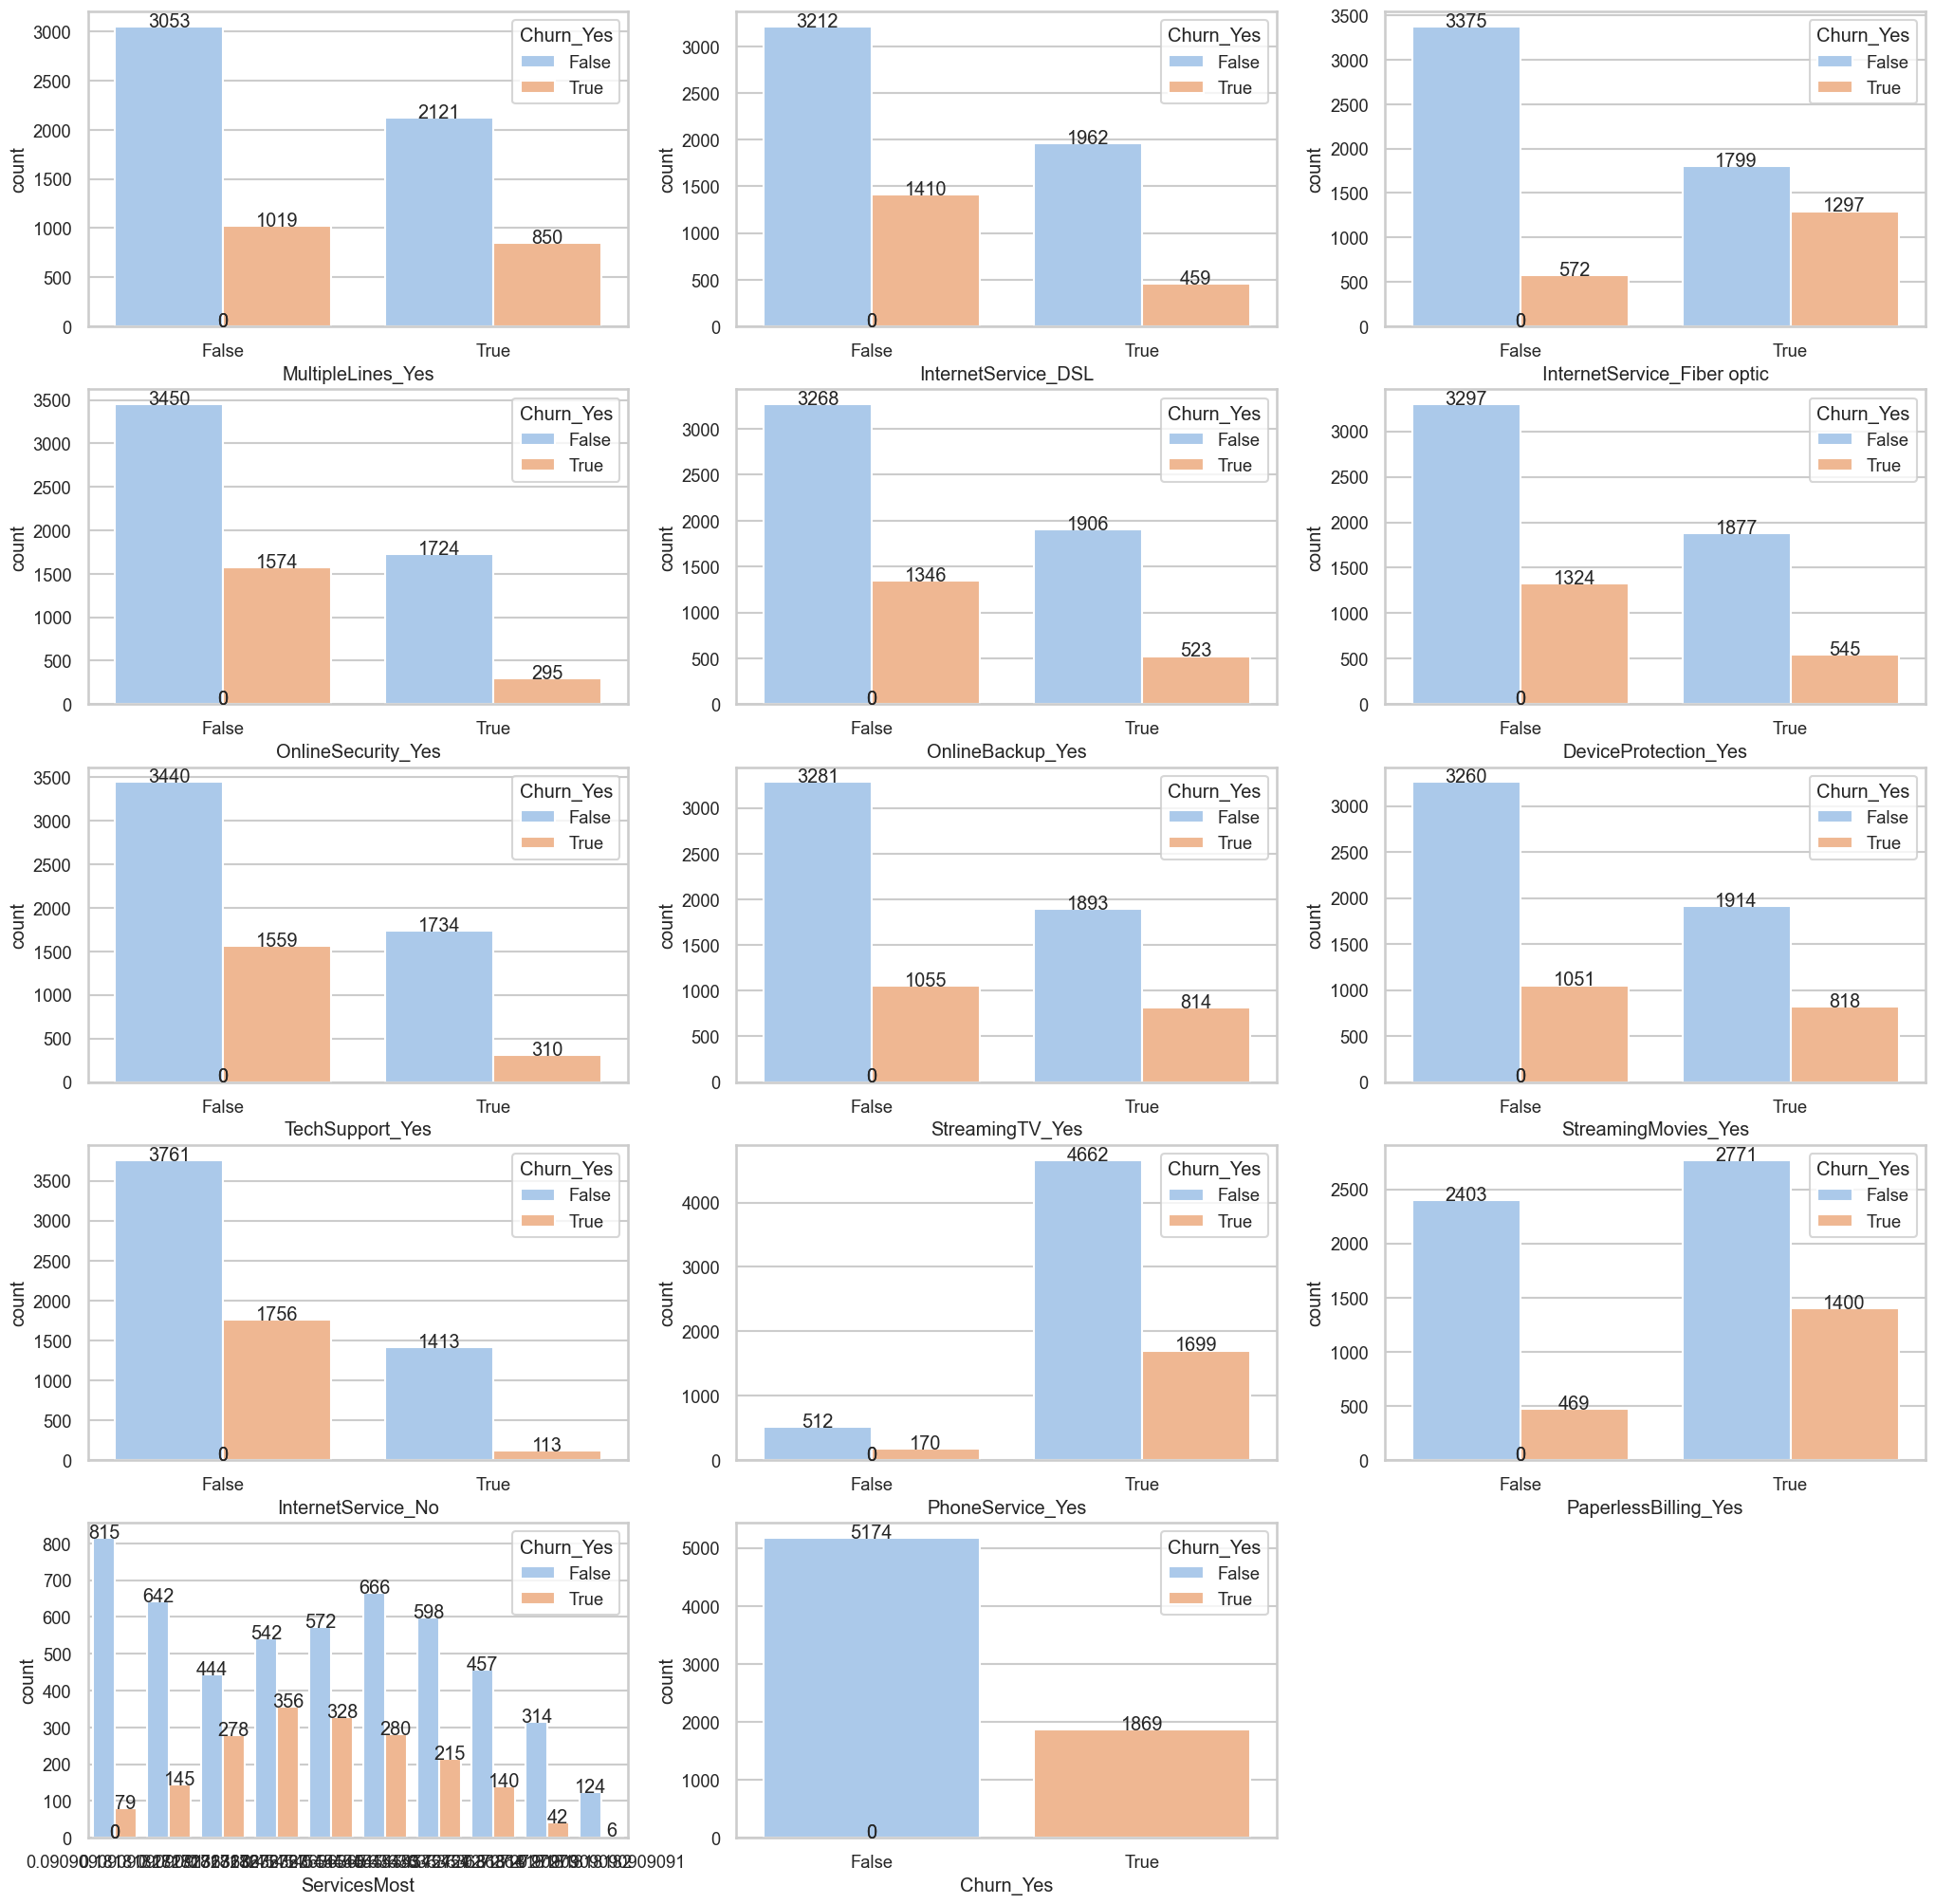

In [62]:
# Create countplot for every services features
plt.figure(figsize=(25,25))
for i, column in enumerate(df_encoded[services]):
    plt.subplot(5, 3, i+1)
    sns.countplot(data=df_encoded[services], x=column, hue="Churn_Yes")
    for p in plt.gca().patches:
        plt.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), ha='center')
plt.show()

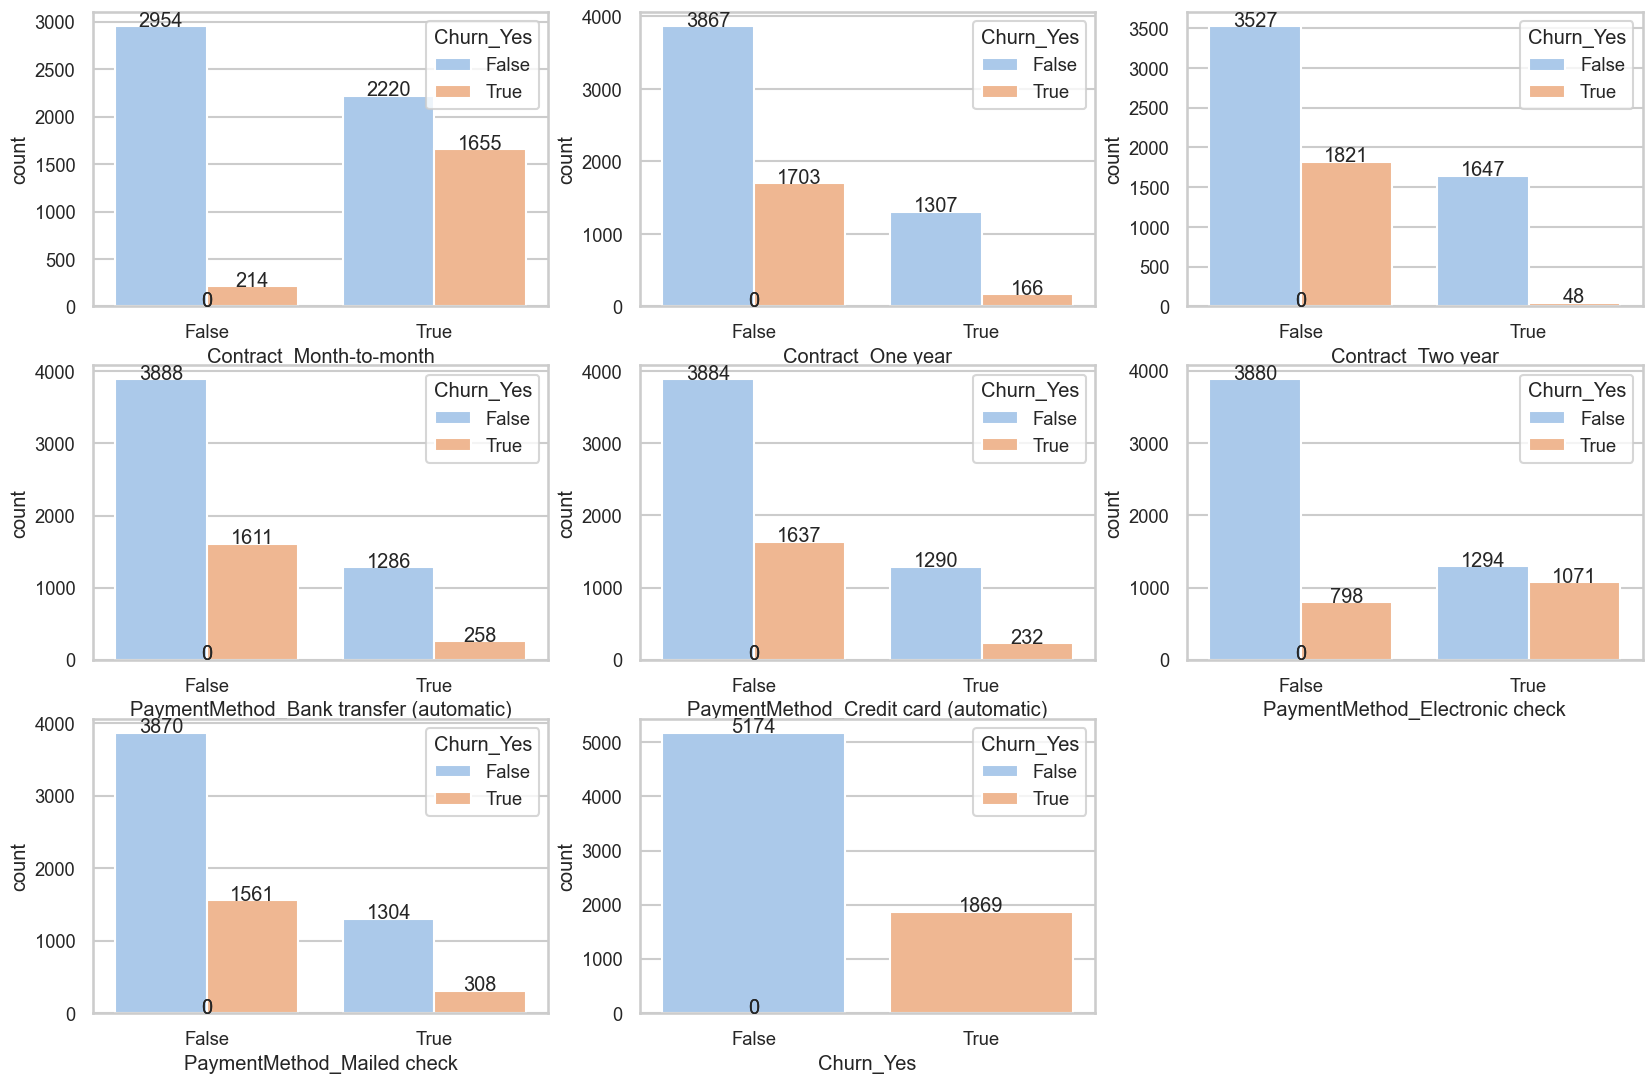

In [64]:
# Create countplot for every other features
plt.figure(figsize=(20,13))
for i, column in enumerate(df_encoded[other]):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df_encoded[other], x=column, hue="Churn_Yes")
    for p in plt.gca().patches:
        plt.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), ha='center')
plt.show()

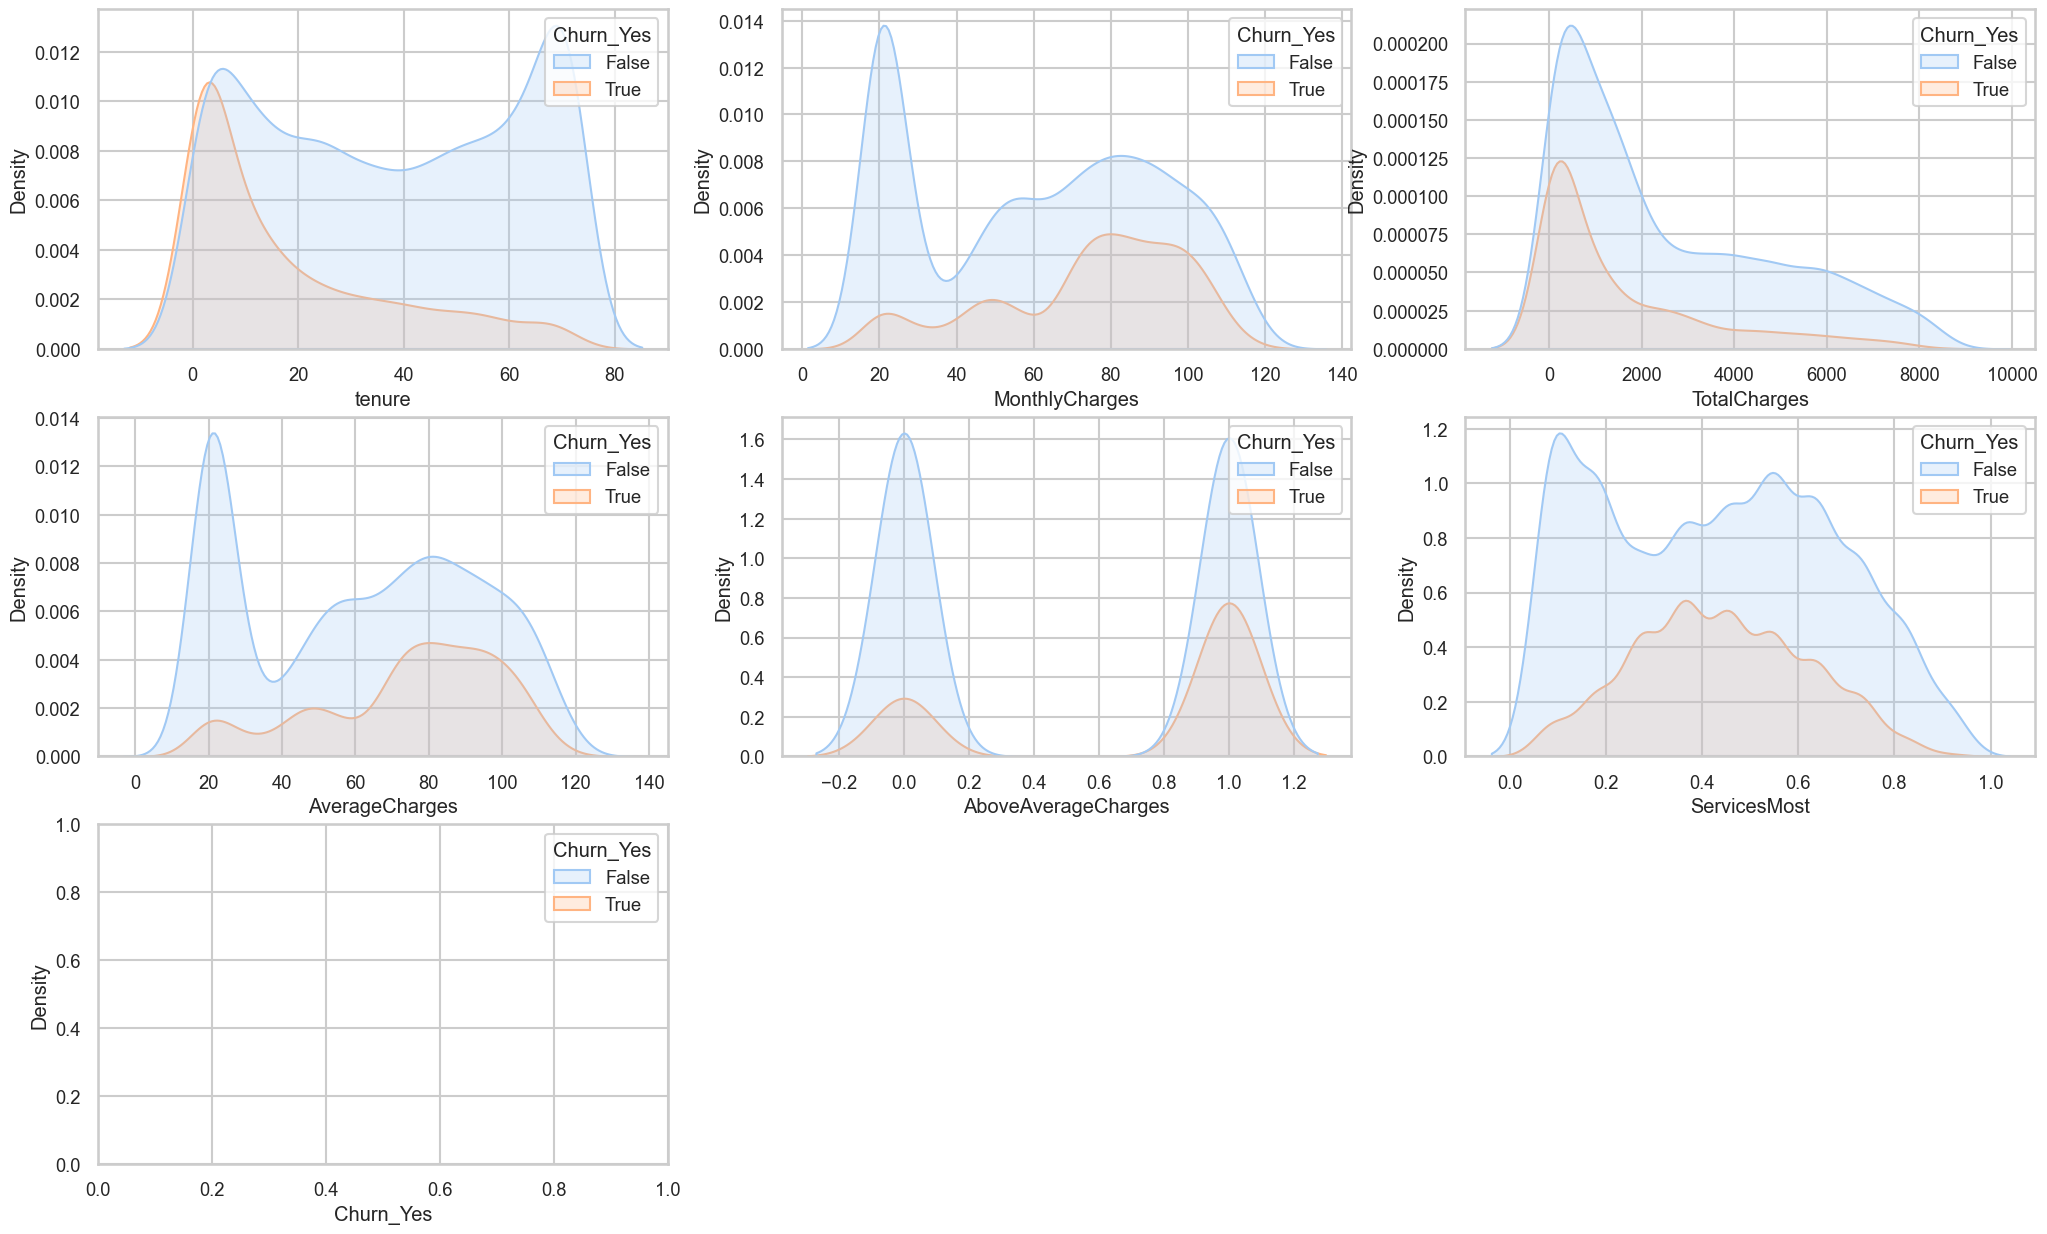

In [65]:
# Examine the distribution of numerical features based on churn
plt.figure(figsize=(25,15))
for i, column in enumerate(df_encoded[numerical]):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=df_encoded[numerical], x=column, fill=True, hue="Churn_Yes", warn_singular=False)
plt.show()

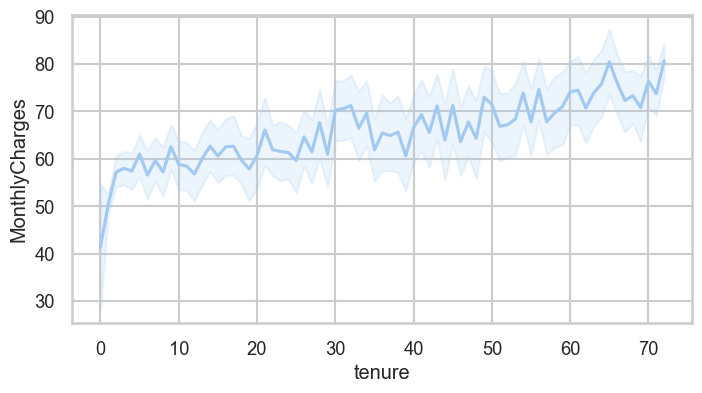

In [66]:
# In conventional scenarios, one might anticipate a negative correlation, where as tenure increases,
# monthly charges decrease or remain stable, as a way of rewarding long-term customers.
sns.lineplot(data=df_encoded, x="tenure", y="MonthlyCharges")
plt.show()

1. **Contract Types:**
   - The countplot reveals a higher churn rate for month-to-month contracts.
   - **Recommendation:** Offer incentives for longer contracts to reduce churn.

2. **Numerical Features:**
   - There is a negative correlation with churn for tenure, total charges, and services most.
   - There is a positive correlation with churn for monthly charges and above-average charges.
   - **Recommendations:**
      - Provide more value-added services and consider reducing monthly charges to enhance overall satisfaction.
      - Implement loyalty programs or rewards to incentivize and retain long-term customers.

3. **Payment Methods:**
   - Customers using electronic check have a higher churn rate.
   - **Recommendation:** Offer a variety of payment options to enhance customer convenience and potentially reduce churn.

4. **Tenure and Monthly Charges:**
   - Customers who churn tend to have lower tenure and higher monthly charges.
   - **Recommendations:**
      - Focus on improving service quality and customer support to retain customers.
      - Evaluate pricing strategies to ensure competitiveness and increase customer loyalty.

**Conclusions:**
- Contract incentives for longer terms have the potential to reduce churn.
- Providing additional value, optimizing pricing models, and rewarding loyalty can enhance overall customer satisfaction.
- Offering diverse payment options is crucial for customer convenience and churn reduction.
- Addressing service quality, customer support, and pricing competitiveness are key elements for customer retention.

**Next Steps:**
- Implement targeted customer retention programs based on identified factors, such as contract types and payment methods.
- Explore further segmentation using the "cluster" feature to tailor retention strategies.
- Continuously monitor and analyze customer feedback for ongoing service improvements.

**Overall Recommendations:**
- Develop comprehensive strategies focusing on customer satisfaction, loyalty incentives, and service enhancements
  to effectively reduce churn and foster long-term customer retention.

# Modeling

In [69]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [70]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import ADASYN
from sklearn.metrics import classification_report, roc_auc_score

In [74]:
# Split the data into features and target
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Scale the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply oversampling to only train data
adasyn = ADASYN(sampling_strategy=1, random_state=0)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

In [75]:
# Create a default XGBoost classifier
model = xgb.XGBClassifier()

# Train the XGBoost model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc)

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.84      0.84      1041
        True       0.54      0.54      0.54       368

    accuracy                           0.76      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409

ROC-AUC Score: 0.8029330075596207


In [78]:
# It's not enough but move on. Let's use same model without feauture engineering
X = data_test.drop("Churn_Yes", axis=1)
y = data_test["Churn_Yes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train.drop(columns=["customerID"]))
X_test = X_test.drop(columns=["customerID"])
X_test = scaler.transform(X_test)
adasyn = ADASYN(sampling_strategy=1, random_state=0)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

In [79]:
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc)

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.84      0.84      1041
        True       0.55      0.55      0.55       368

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC Score: 0.8076016476632
